In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes

In [29]:
data = load_diabetes()

df = pd.DataFrame(data = data.data, columns = data.feature_names)
df['target'] = data.target

X = df.drop(columns = 'target')
y = df['target']

In [56]:
class LinearRegression:
    
    def __init__ (self, learning_rate = 0.01, epochs = 1000):
        """
        Initialize the Linear Regression model.
        """
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0
        self.cost_history = []

    def fit(self, X, y):
        """
        Train the model using Gradient Descent.
        :param x: Input features (1D array).
        :param y: Target values (1D array).
        """

        X = np.array(X)
        y = np.array(y)
        m, n = X.shape  # (m) number of samples, (n) number of features

        self.weights = np.zeros(n)

        for epoch in range(self.epochs):

            # Make Prediction
            y_pred = np.dot(X, self.weights) + self.bias

            # Calculate Gradients
            dm = -(2/m) * np.dot(X.T, (y - y_pred)) # Gradient for weights
            db = -(2/m) * np.sum(y - y_pred)        # Gradient for Bias

            # Update Weights and bias
            self.weights -= self.learning_rate * dm
            self.bias   -= self.learning_rate * db

            # calculate the cost and record it (MSE)
            cost = np.sum((y - y_pred) ** 2) / m
            self.cost_history.append(cost)

            # Print cost every 100 epochs for progress tracking
            if epoch % 100 == 0:
                print(f'Epoch {epoch}, Cost {cost:.4f}')

    def predict(self, X):
        """
        Predict the target values for given input features.
        :param x: Input features (1D array).
        :return: Predicted target values.
        """
        return self.weights * X + self.bias
    
    def plot_cost (self):
        """
        Plot the cost function over epochs.
        """
        plt.plot(range(self.epochs), self.cost_history)
        plt.title('Cost Function over Epochs', fontsize = 16, fontweight = 'bold')
        plt.xlabel('Epoch', fontsize = 12)
        plt.ylabel('Cost (MSE)', fontsize = 12)
        plt.show()

Epoch 0, Cost 29074.4819
Epoch 100, Cost 6259.9112
Epoch 200, Cost 5785.4214
Epoch 300, Cost 5706.1760
Epoch 400, Cost 5636.1300
Epoch 500, Cost 5568.4161
Epoch 600, Cost 5502.8387
Epoch 700, Cost 5439.3221
Epoch 800, Cost 5377.7954
Epoch 900, Cost 5318.1903


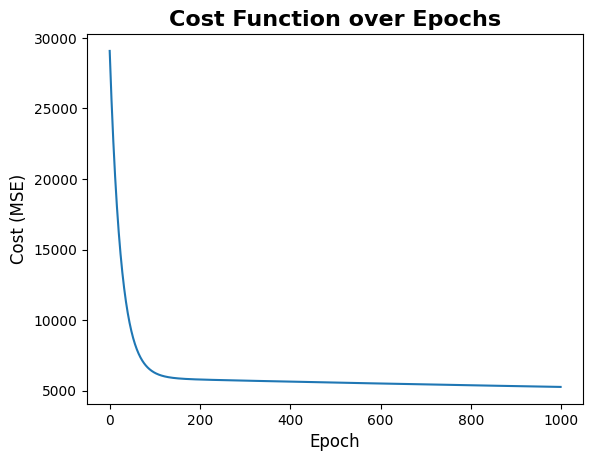

In [57]:
model = LinearRegression(learning_rate = 0.01, epochs = 1000)
model.fit(X, y)
model.plot_cost()